# Exploratory Data Analysis

## Objective

This notebook performs exploratory data analysis (EDA) on the HR employee attrition dataset to identify characteristics of the workforce, examine patterns associated with turnover, detect relationships among variables, and uncover multicollinearity. The insights generated here will guide subsequent feature selection, preprocessing, and model development.

---

# 1. Setup and Data Loading

We import libraries for data manipulation (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and configure standard warning filters. We load custom plot configurations from `src.plot_config` and import the raw dataset `Employee_Data.csv`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.plot_config import *

df = pd.read_csv("../data/raw/Employee_Data.csv")

---

# 2. Feature Identification

We segment the dataset into numerical and categorical subgroups to facilitate target-specific statistical analysis and plotting.

### Numerical Features

We isolate all numerical columns (continuous and discrete integers) in the DataFrame to inspect their scales, skewness, and spreads.

In [2]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(f"Number of numerical features: {len(numerical_columns)}")

numerical_columns

Number of numerical features: 26


Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

### Categorical Features

We isolate all categorical variables (text object columns) to study workforce distributions across organizational attributes.

In [20]:
categorical_columns = df.select_dtypes(include="object").columns

print(f"Number of categorial features: {len(categorical_columns)}")

categorical_columns

Number of categorial features: 9


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

---

# 3. Univariate Analysis

We examine the individual distributions of our numerical features and categorical attributes to understand the shape of the dataset and spot target imbalances.

### 3.1 Numerical Feature Distributions

We plot histograms with kernel density estimates (KDE) for all numerical features to evaluate their statistical distributions, check for severe skewness, and detect potential outliers.

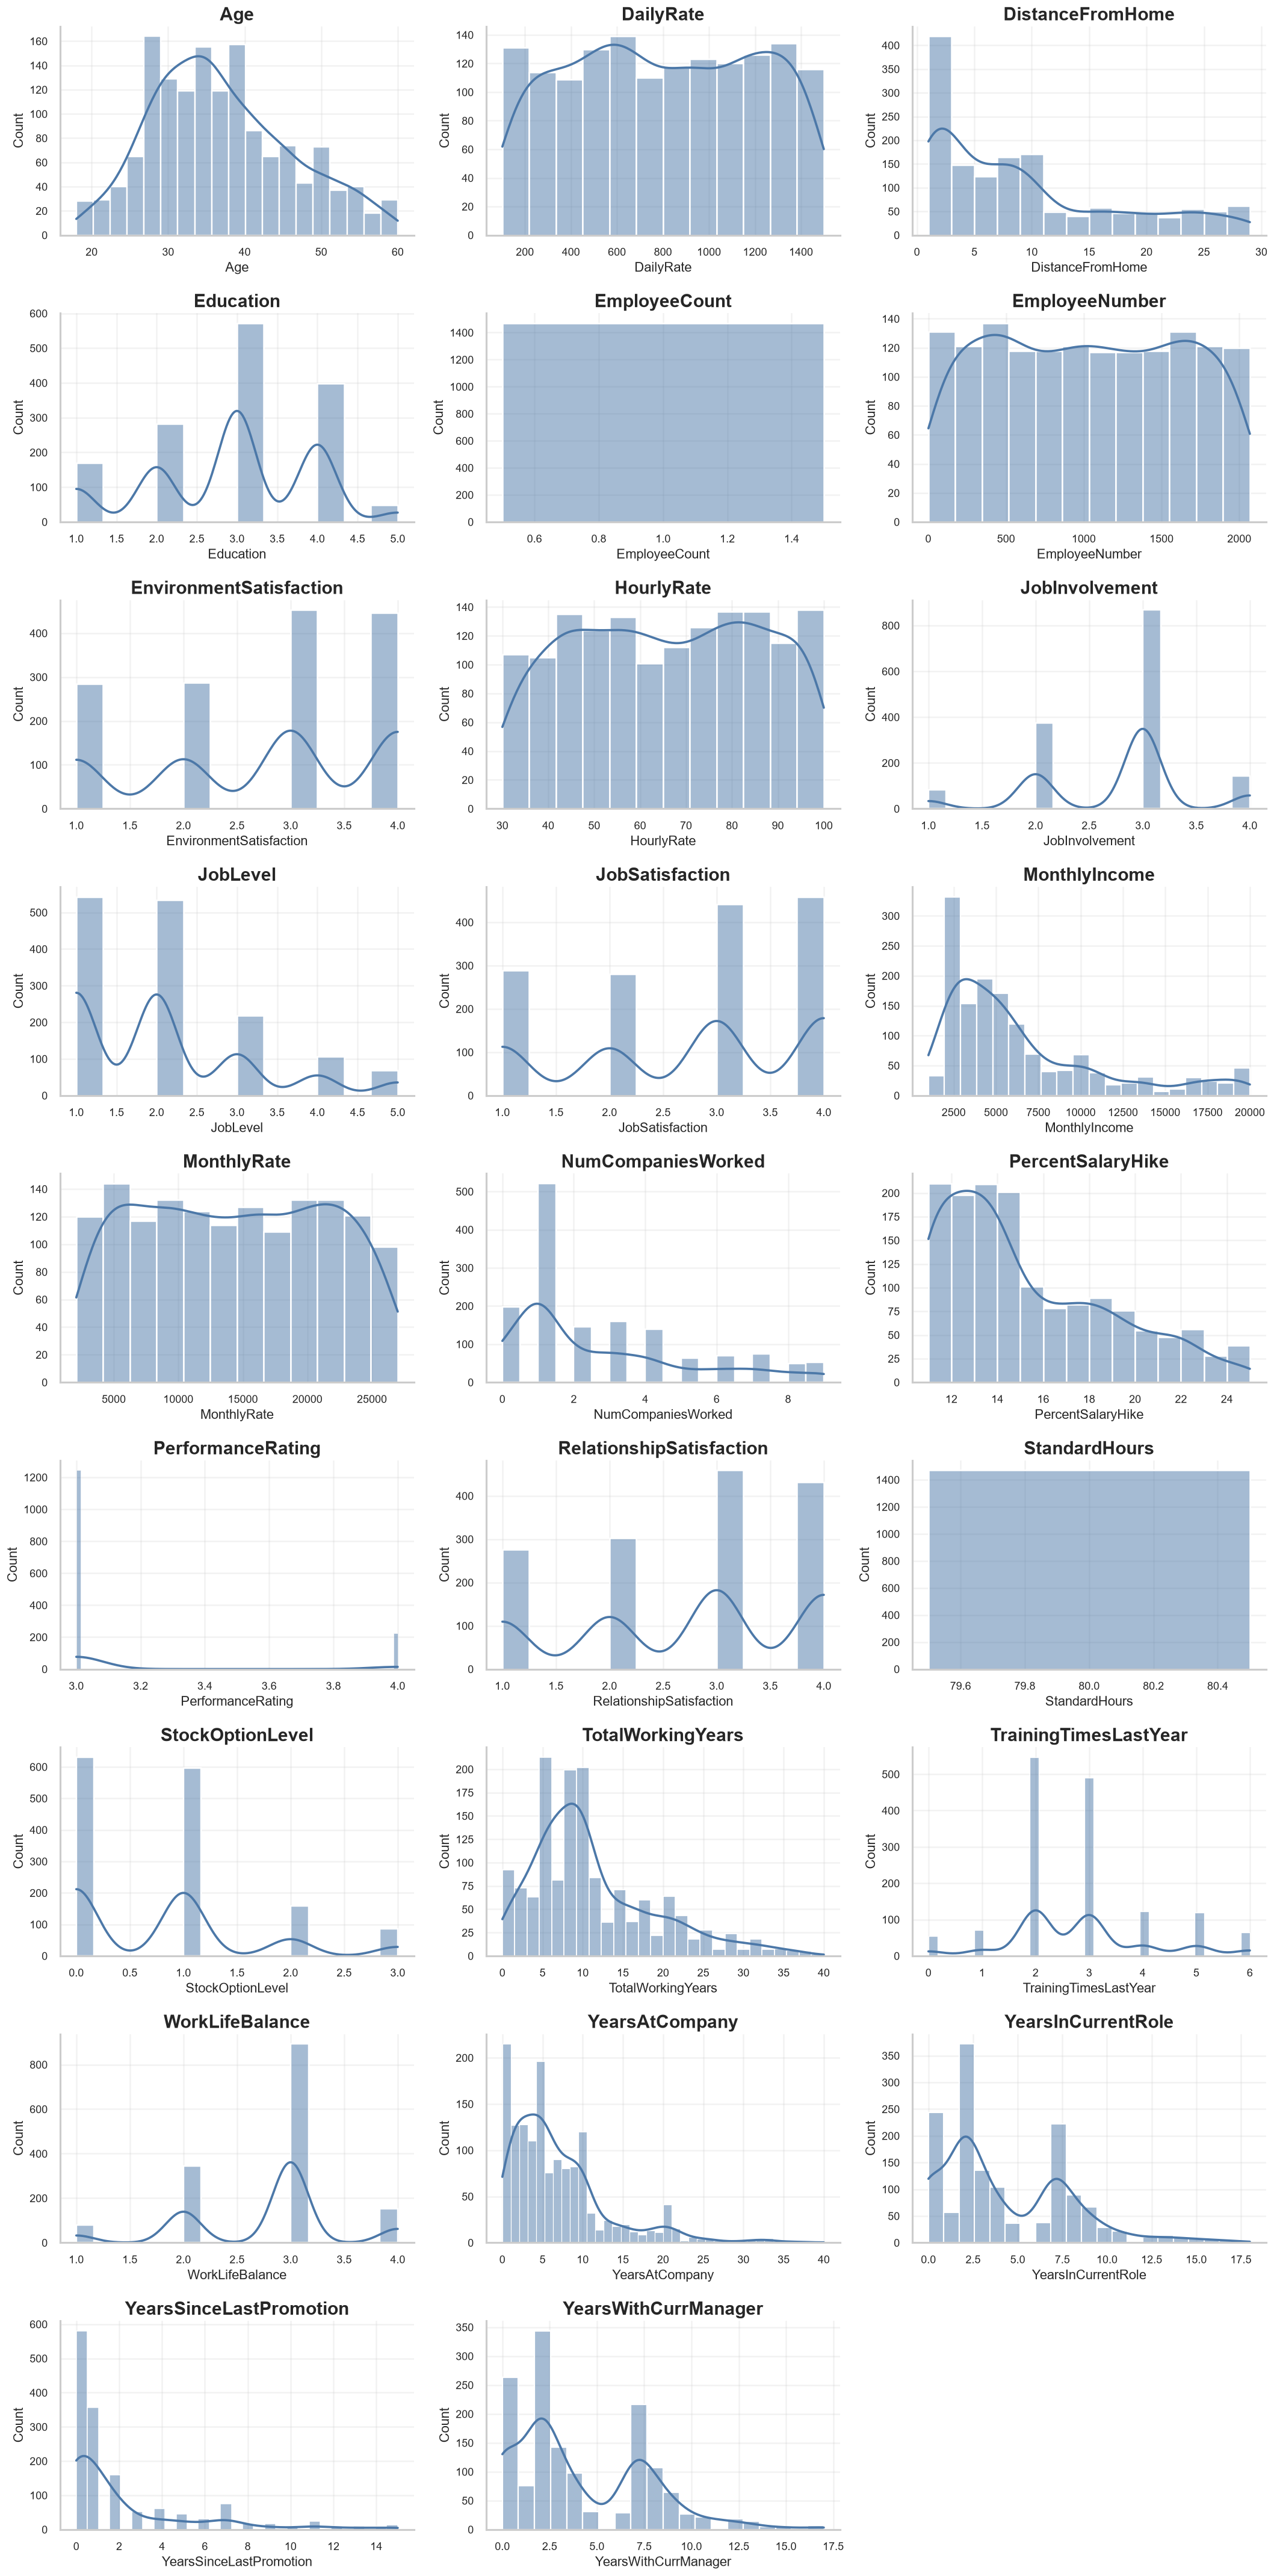

In [3]:
cols = 3

rows = int(np.ceil(len(numerical_columns) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))

axes = axes.flatten()

for i, col in enumerate(numerical_columns):

    sns.histplot(
        df[col],
        kde=True,
        color=PRIMARY,
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

### 3.2 Categorical Feature Distributions

We plot categorical feature counts segmented by our target variable `Attrition` to understand how the raw volume of employees distributes across different subgroups.

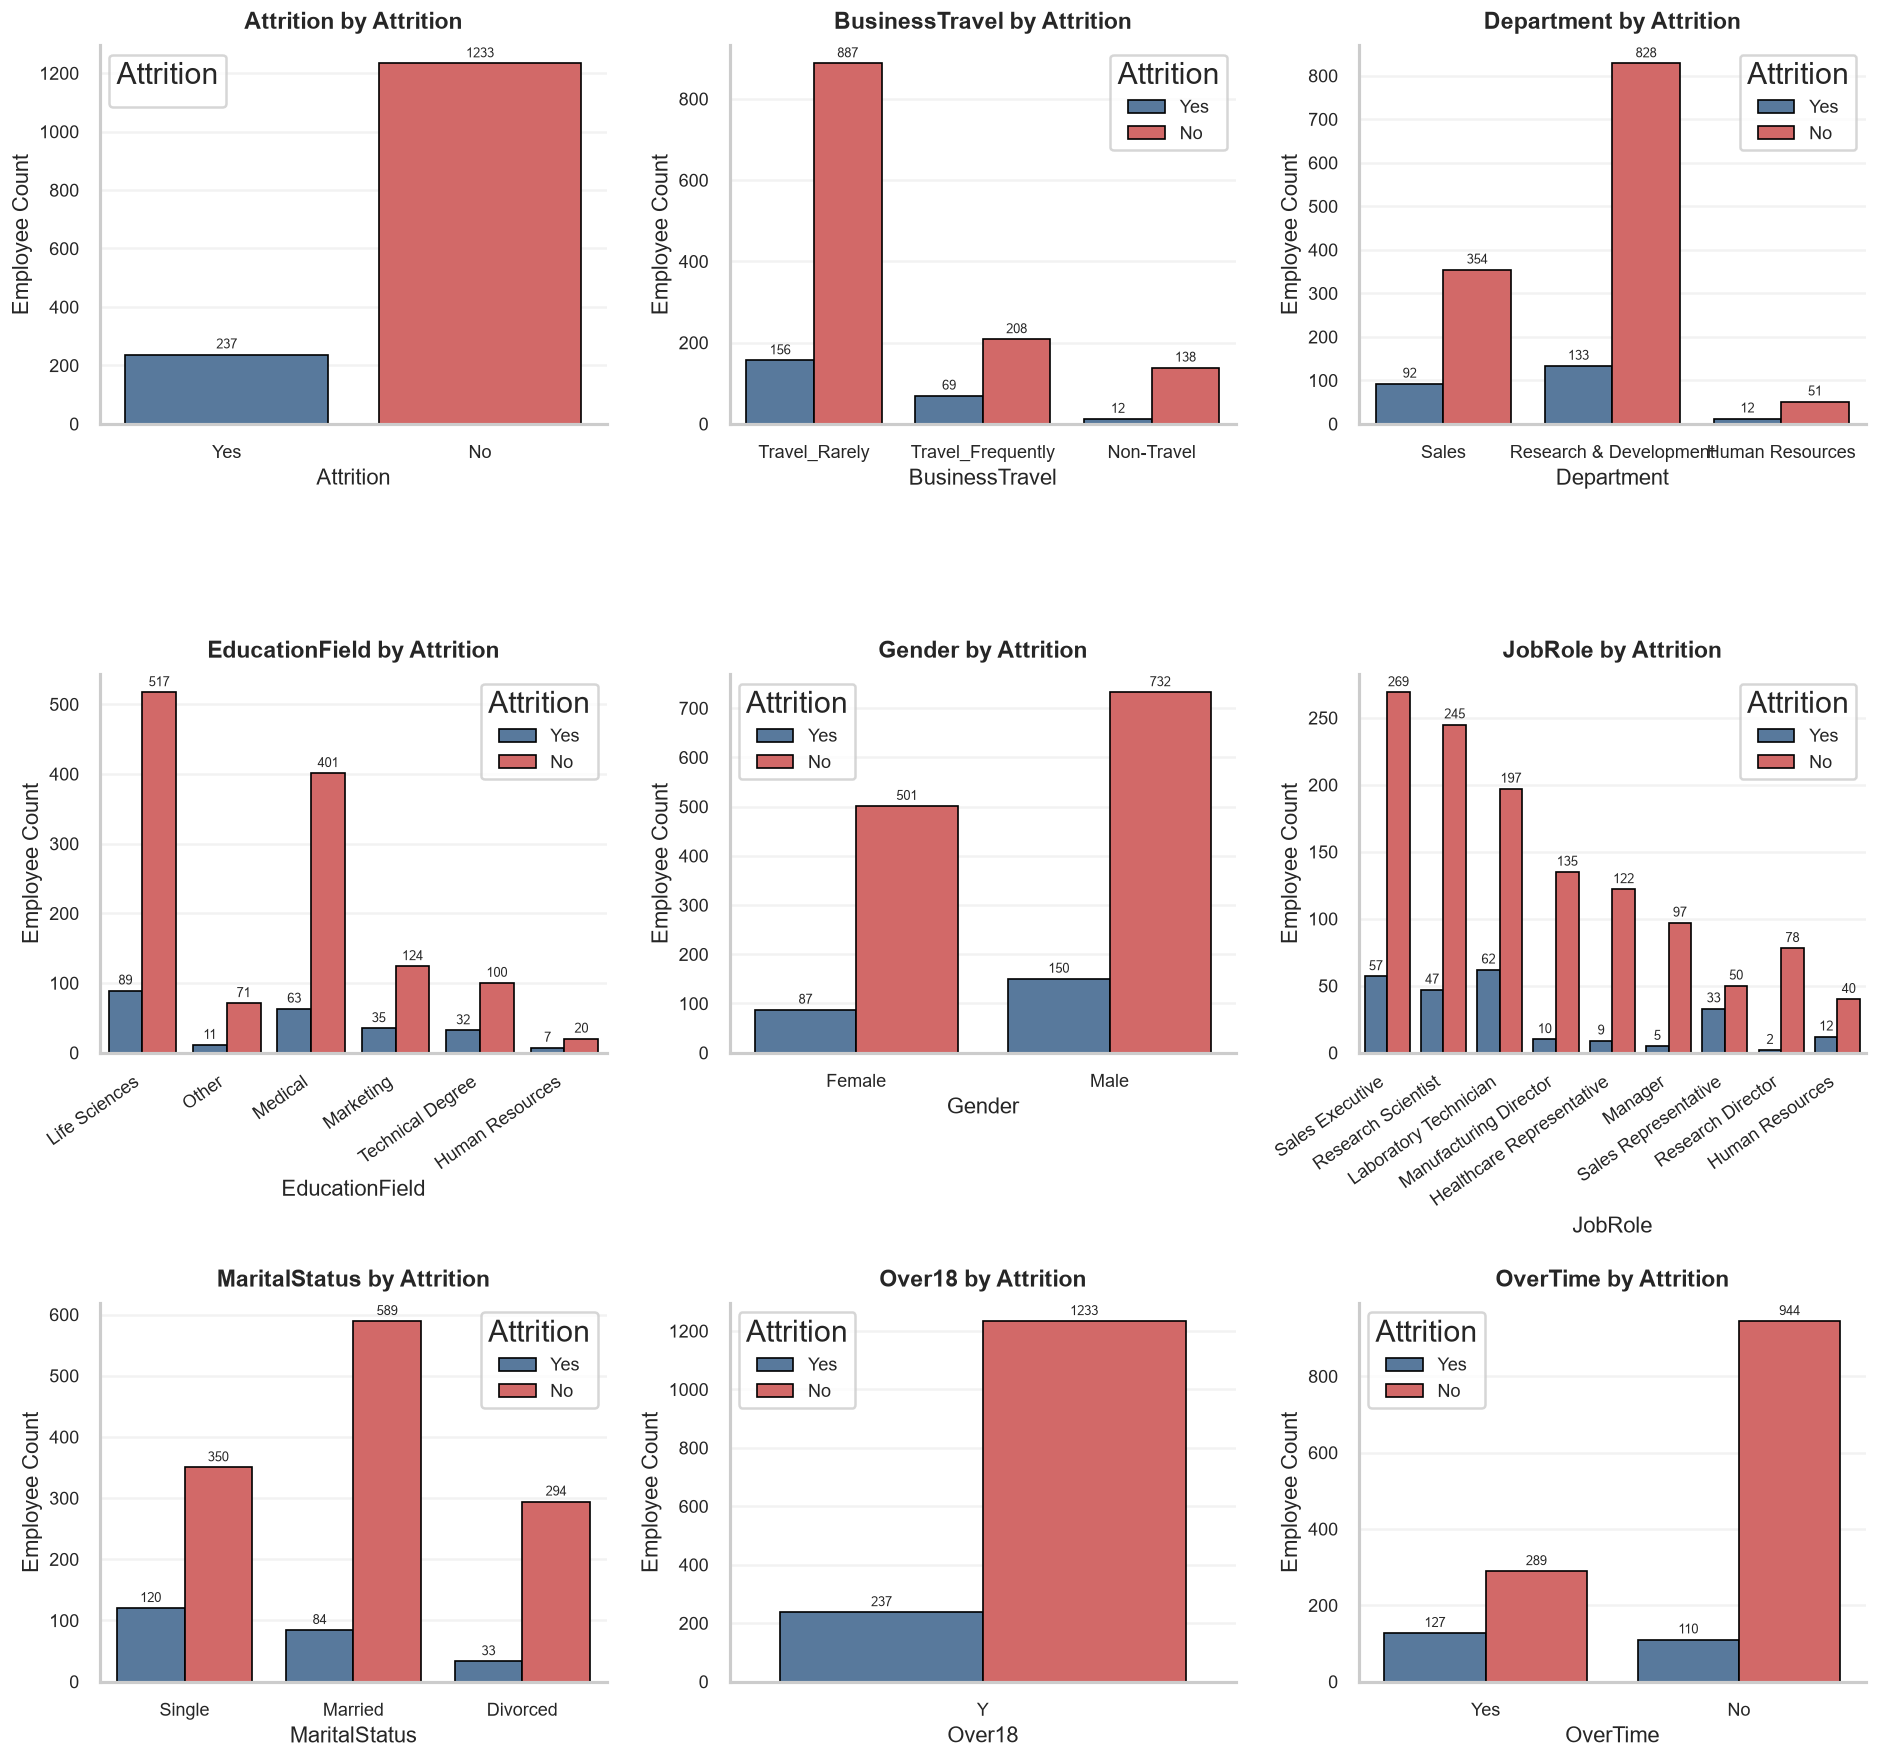

In [30]:
cols = 3
rows = int(np.ceil(len(categorical_columns) / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, rows * 5)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_columns):

    plot = sns.countplot(
        data=df,
        x=feature,
        hue="Attrition",
        palette=[PRIMARY, DANGER],
        edgecolor="black",
        linewidth=1,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} by Attrition",
        fontsize=14,
        pad=10
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Employee Count")

    # Rotate long labels only when needed
    if feature in ["JobRole", "EducationField"]:
        axes[i].tick_params(axis="x", rotation=35)
        for label in axes[i].get_xticklabels():
            label.set_horizontalalignment("right")

    # Add count labels
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            padding=2,
            fontsize=8
        )

    axes[i].legend(title="Attrition")

    sns.despine(ax=axes[i])

# Remove empty subplot(s)
for j in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---

# 4. Bivariate Analysis

We evaluate the direct relationships between our predictor features and employee attrition to isolate factors that correlate with employee turnover.

### 4.1 Numerical Features vs Attrition

We construct boxplots comparing each numerical feature across the `Attrition` target groups (`Yes` and `No`) to visualize difference in distribution centers, spreads, and outlier concentrations.

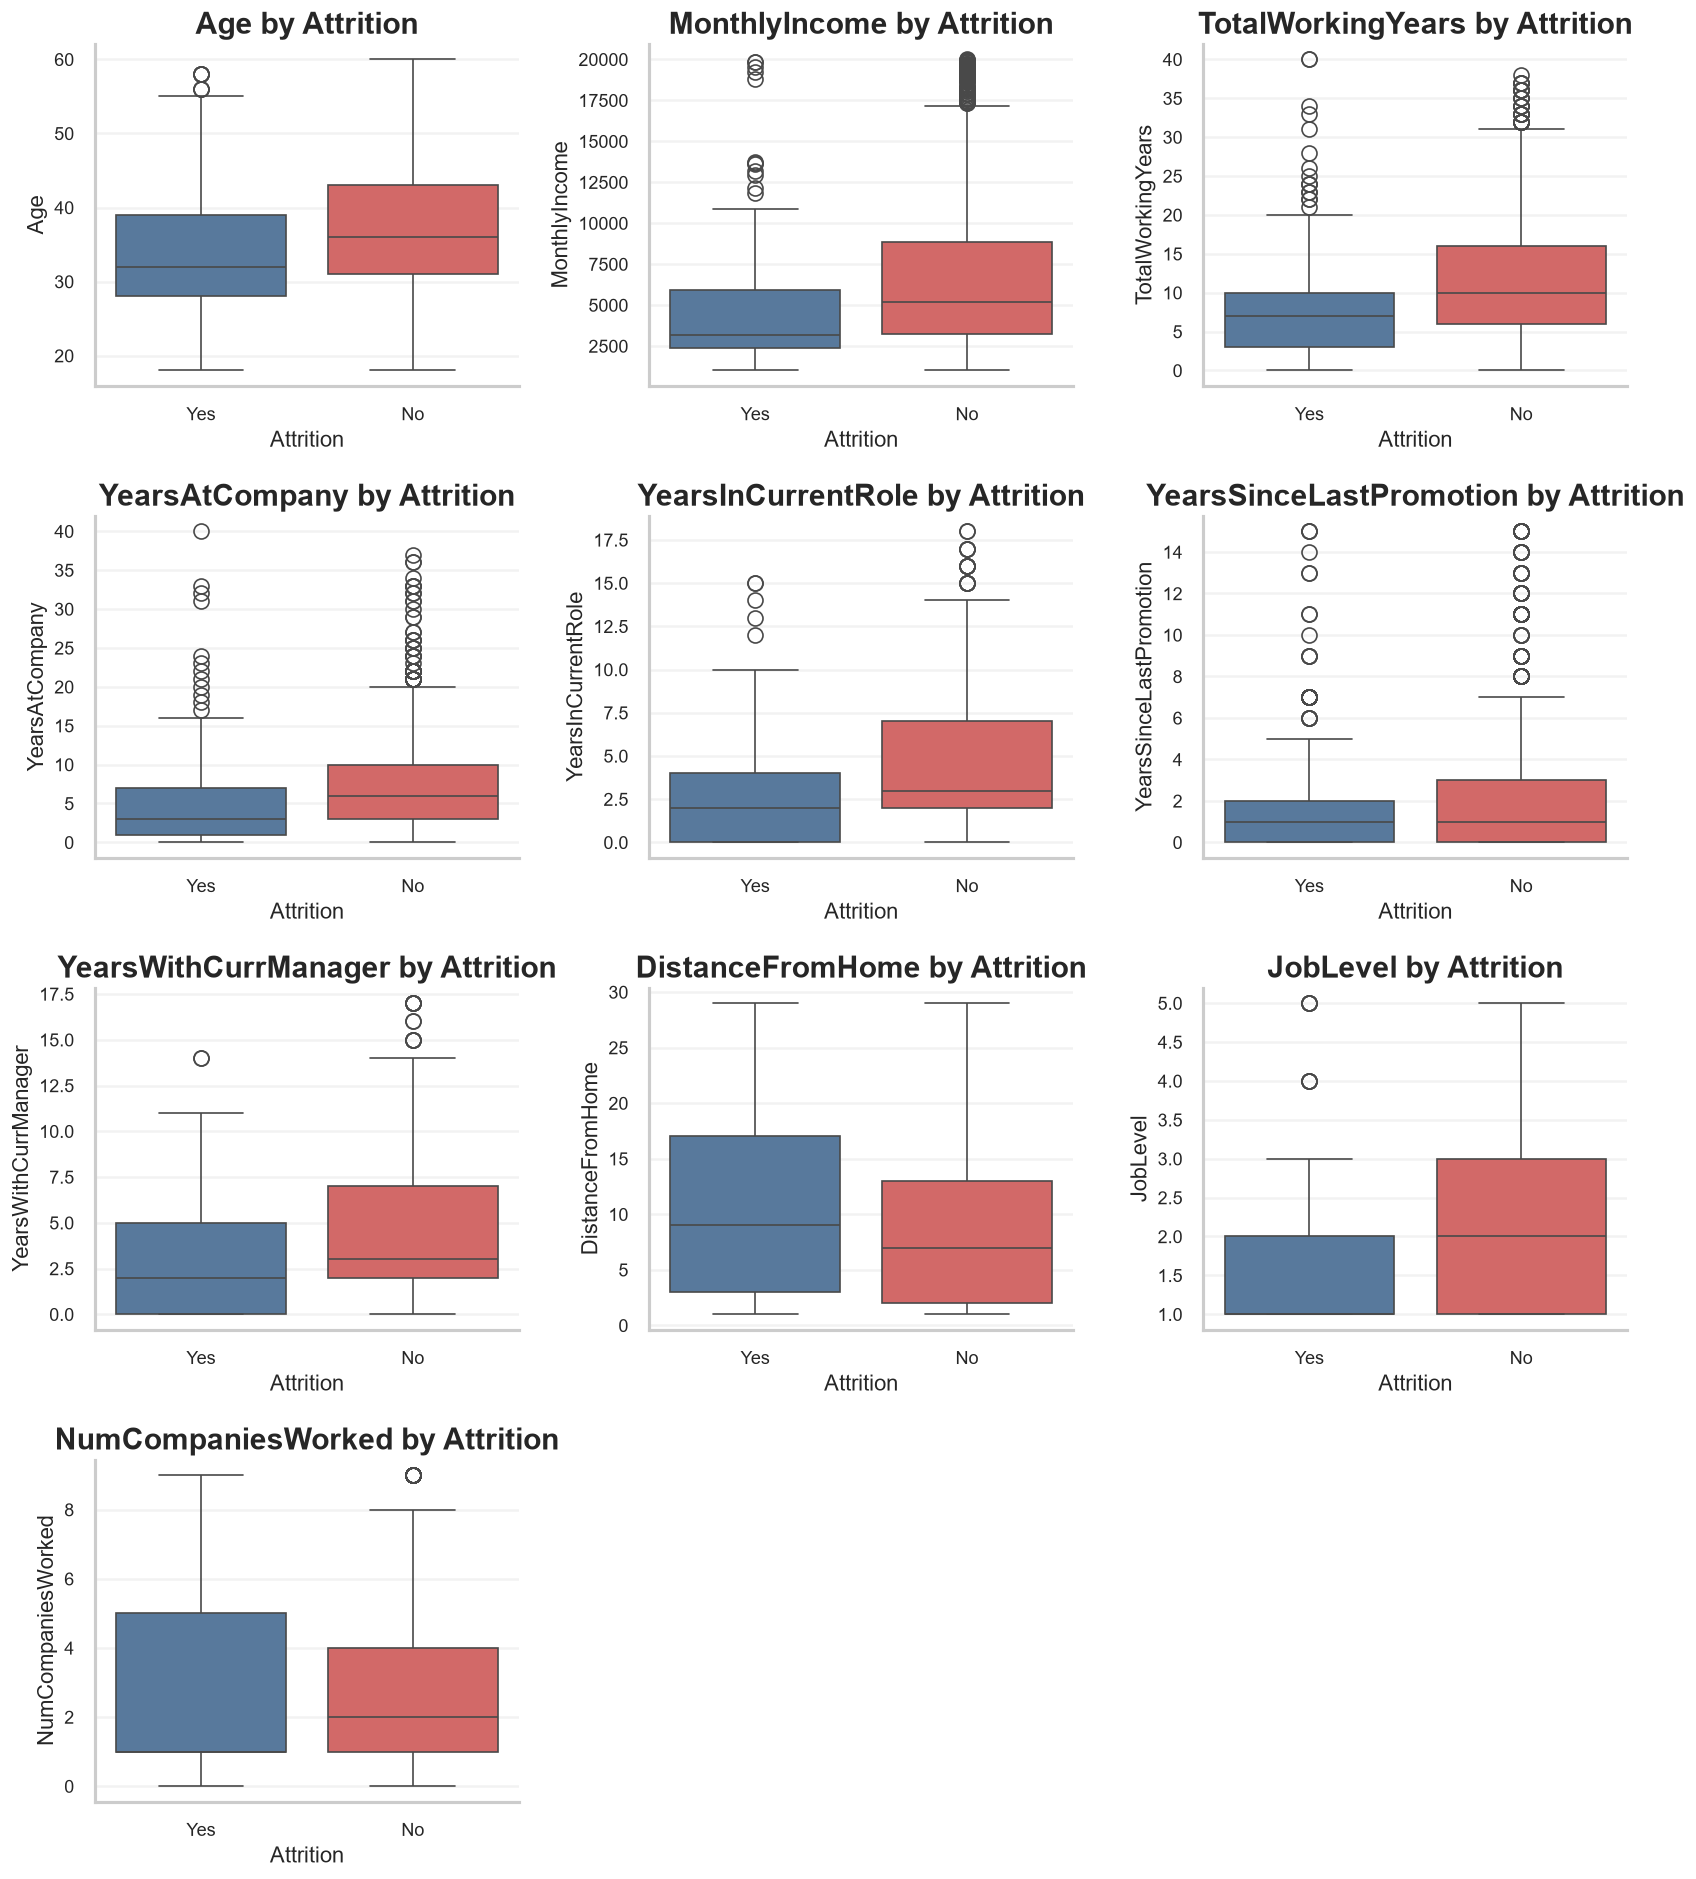

In [ ]:


num_feat =  [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "DistanceFromHome",
    "JobLevel",
    "NumCompaniesWorked"
]

cols = 3
rows = int(np.ceil(len(num_feat) / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, rows * 4)
)

axes = axes.flatten()

for i, feature in enumerate(num_feat):

    sns.boxplot(
        data=df,
        x="Attrition",
        y=feature,
        hue="Attrition",
        palette=[PRIMARY, DANGER],
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Attrition")
    axes[i].set_xlabel("Attrition")
    axes[i].set_ylabel(feature)

    sns.despine(ax=axes[i])

# Remove unused subplot(s)
for j in range(len(num_feat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Key Findings: Numerical Features vs Attrition

* **Age & Career Stage**: Younger employees (particularly those under 30) exhibit higher attrition rates. The median age of employees who leave is noticeably lower than those who stay.
* **Monthly Income & Job Level**: There is a strong inverse relationship between compensation and attrition. Employees who leave generally have lower monthly incomes and lower job levels.
* **Experience & Tenure**: Employees with fewer total working years and shorter tenure at the company (less than 3 years) show higher turnover. Short manager tenure also correlates with attrition.
* **Commute Distance**: Employees who leave tend to have longer commutes, as shown by higher values in `DistanceFromHome`.
* **Outliers & Distribution**: Columns like `MonthlyIncome` and `YearsSinceLastPromotion` contain positive outliers, representing long-tenured/high-earning exceptions.

### 4.2 Categorical Features vs Attrition

We generate normalized crosstabs and display them as stacked bar charts to evaluate relative attrition percentages within each categorical group level.

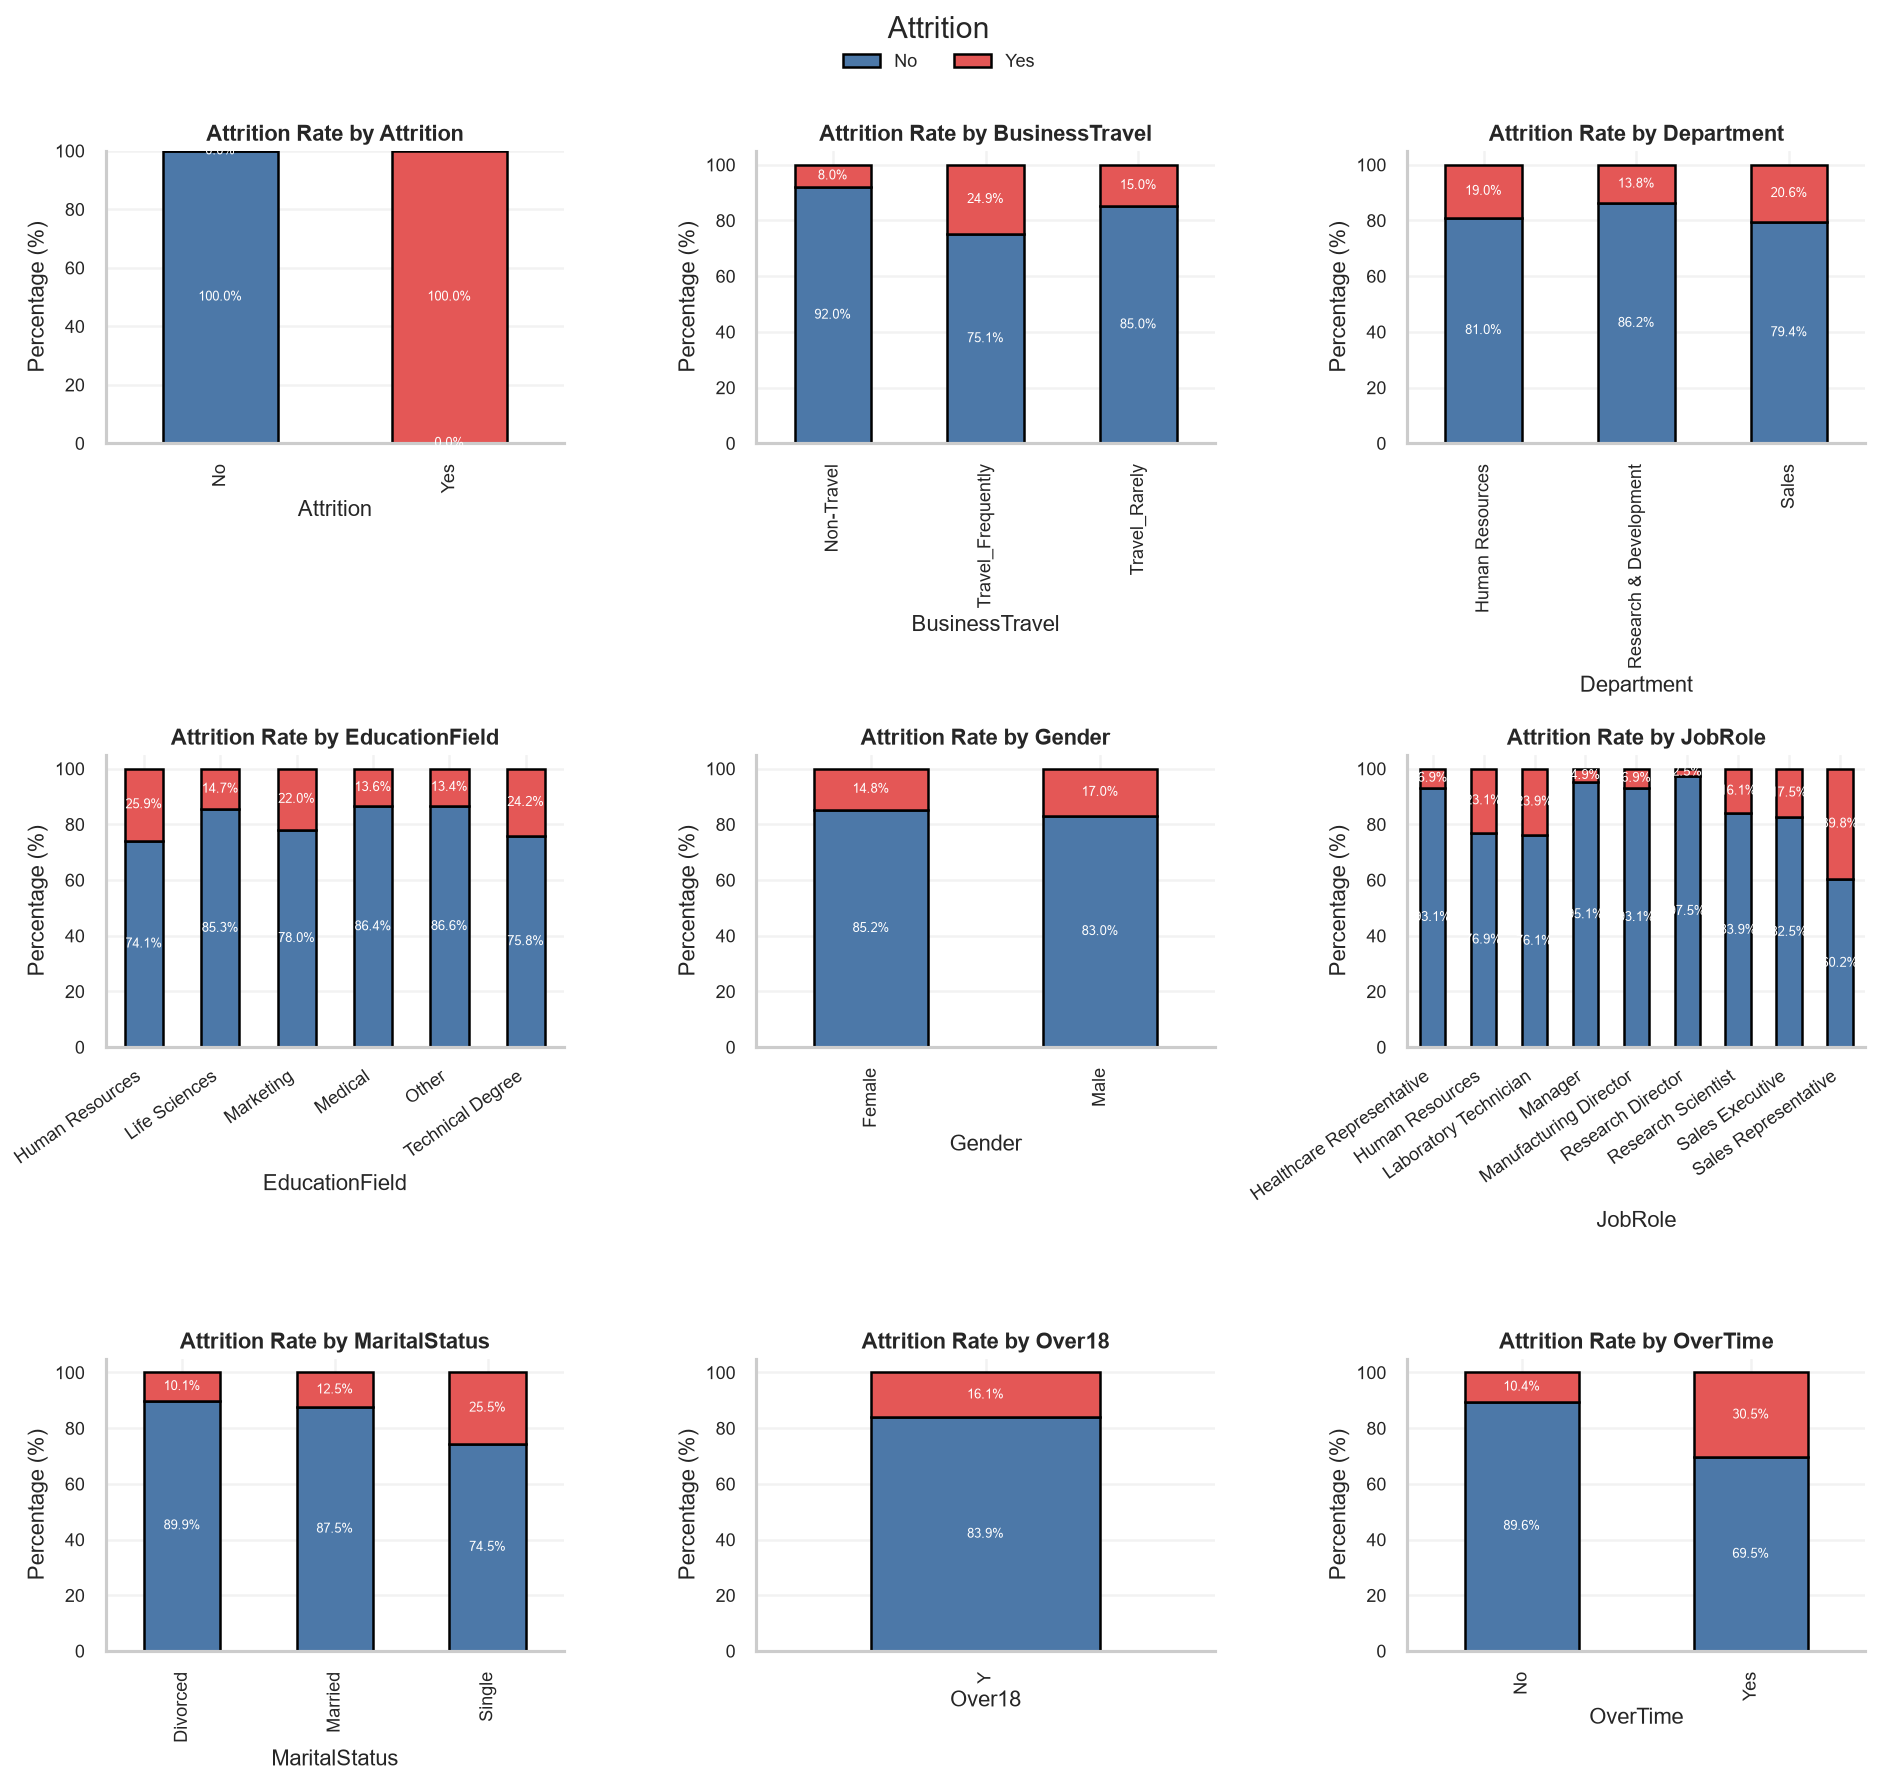

In [ ]:
cols = 3
rows = int(np.ceil(len(categorical_columns) / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, rows * 5)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_columns):

    temp = (
        pd.crosstab(
            df[feature],
            df["Attrition"],
            normalize="index"
        ) * 100
    )

    temp.plot(
        kind="bar",
        stacked=True,
        color=[PRIMARY, DANGER],
        edgecolor="black",
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(f"Attrition Rate by {feature}", fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Percentage (%)")

    if feature in ["JobRole", "EducationField"]:
        axes[i].tick_params(axis="x", rotation=35)
        for label in axes[i].get_xticklabels():
            label.set_horizontalalignment("right")

    # Percentage labels
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt="%.1f%%",
            label_type="center",
            fontsize=8,
            color="white"
        )

    sns.despine(ax=axes[i])

# One common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Attrition",
    loc="upper center",
    ncol=2,
    frameon=False
)

# Remove empty subplot(s)
for j in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Key Findings: Categorical Features vs Attrition

* **Overtime Impact**: Employees who work overtime exhibit a significantly higher rate of attrition compared to those who do not work overtime.
* **Business Travel**: Frequent business travelers show elevated attrition rates compared to rare travelers or non-travelers.
* **Job Role & Department**: Sales Representatives, Lab Technicians, and Human Resources roles experience the highest turnover rates, whereas Research Directors and Managers have the lowest attrition. The Sales department overall has a higher rate of attrition than R&D.
* **Marital Status**: Single employees leave at a higher rate compared to married or divorced employees.
* **Education Field**: Life Sciences and Medical fields show lower percentage rates of attrition (but higher total volume), while Technical Degrees and Marketing fields display higher rates of attrition.

---

# 5. Correlation Analysis

We quantify linear dependencies between numerical features to screen for multicollinearity and identify variables with strong linear associations to attrition.

### Correlation Matrix

We calculate the Pearson correlation coefficients among all numerical columns and plot a heatmap to check for potential multicollinearity issues.

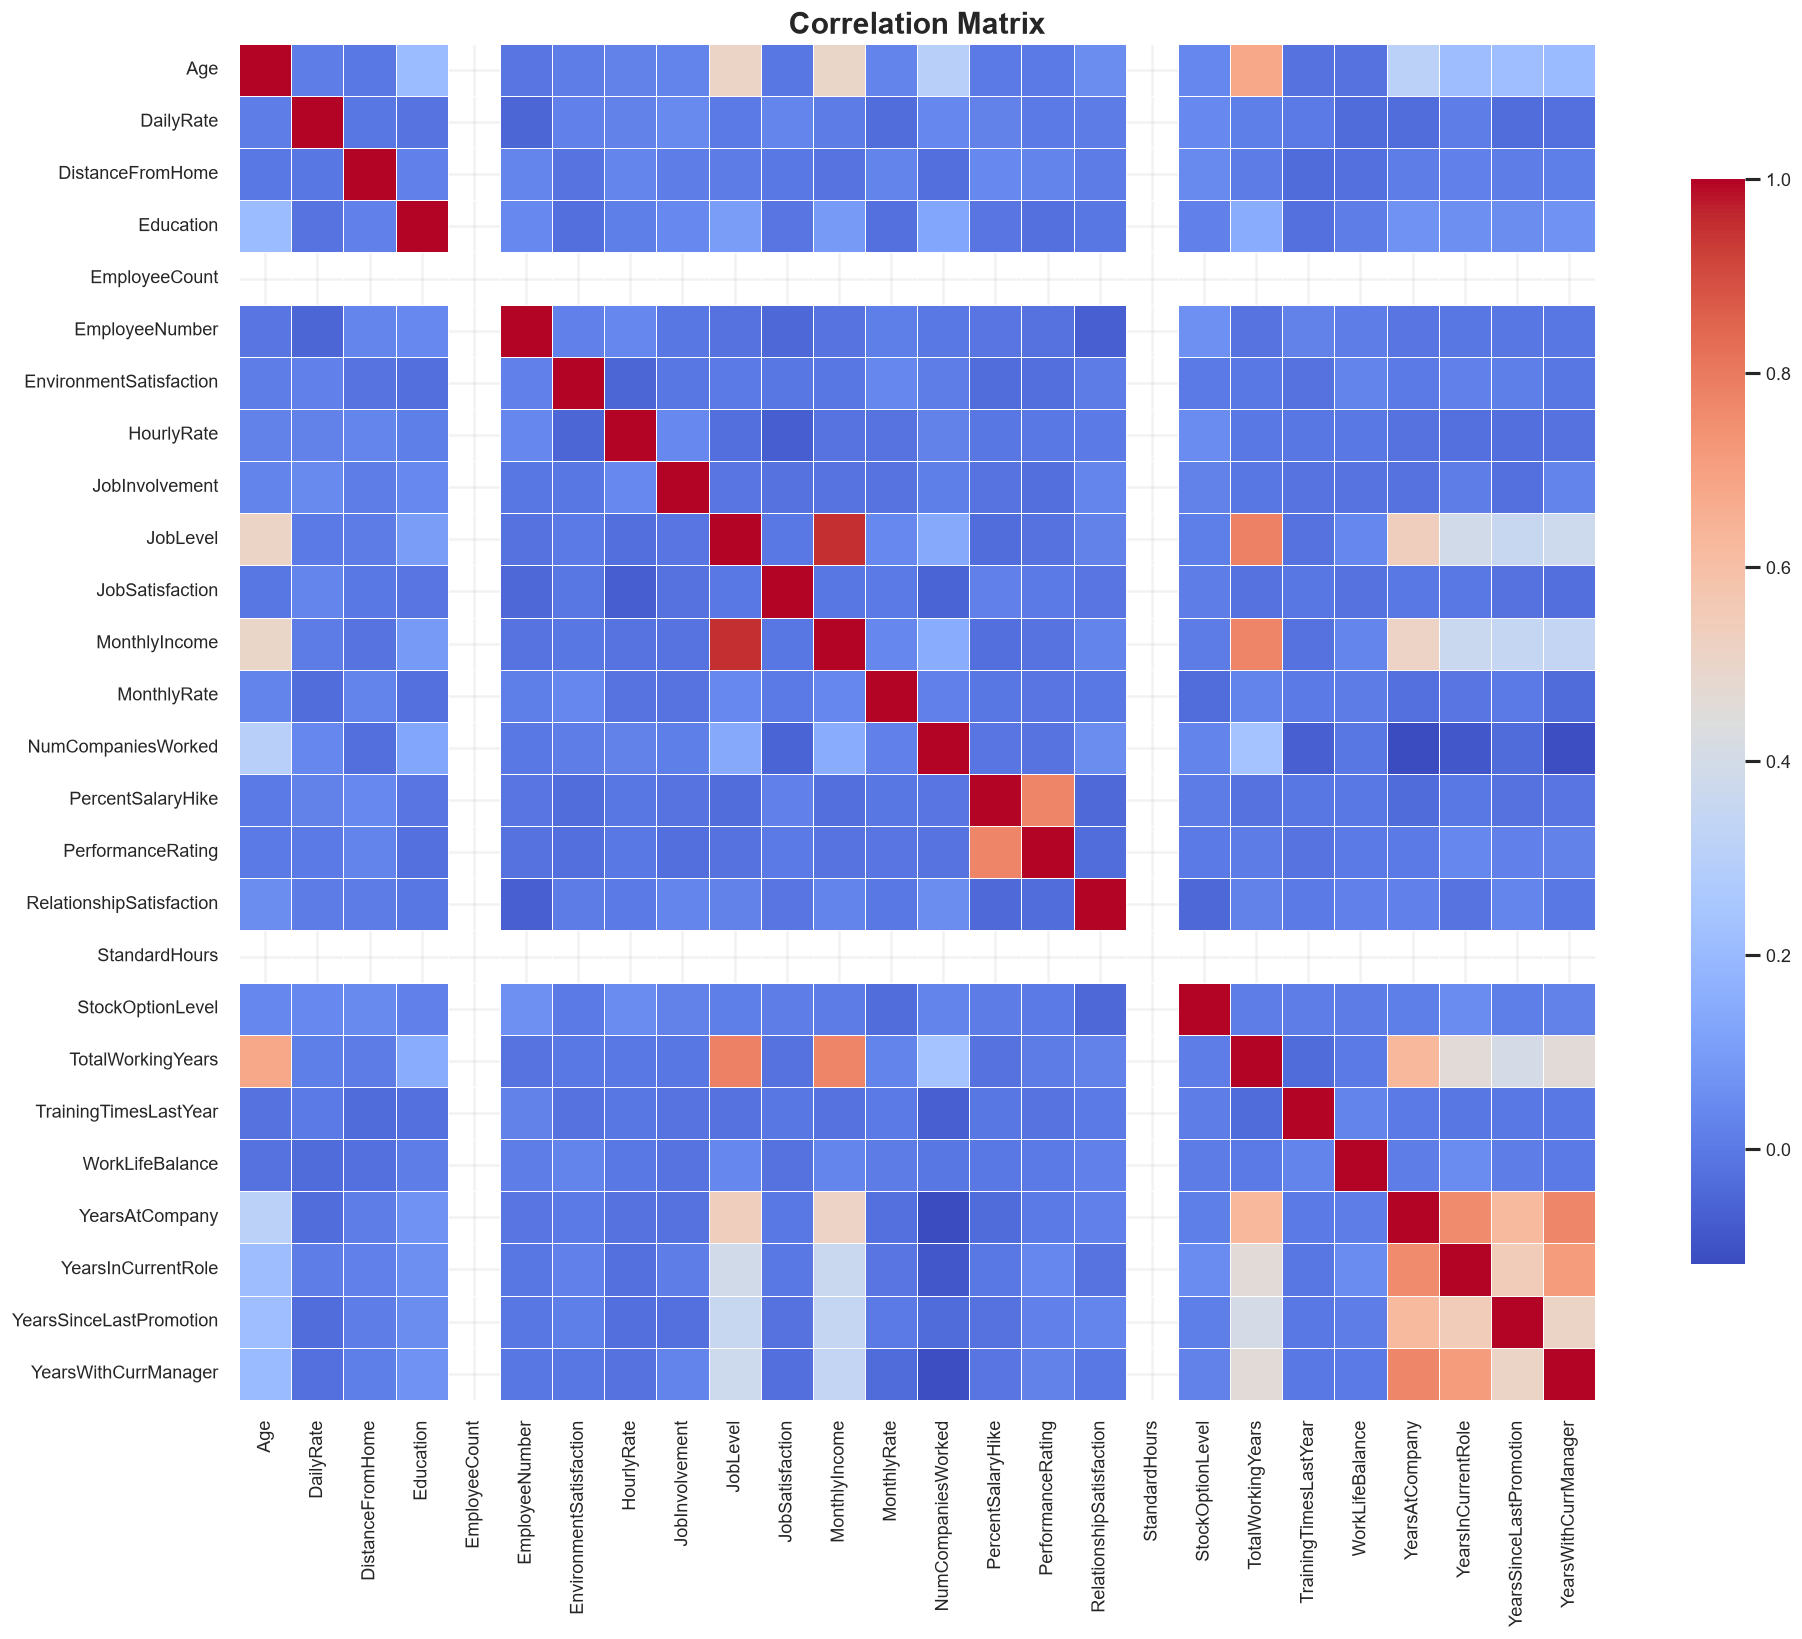

In [12]:
corr = df.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap=DIVERGING,
    annot=False,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8},
    ax=ax
)

ax.set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Key Findings: Correlation Heatmap

* **High Multicollinearity**: Strong positive correlations exist between:
  - `JobLevel` and `MonthlyIncome` (near 0.95), indicating these features represent the same underlying organizational level.
  - `TotalWorkingYears` and `JobLevel`/`MonthlyIncome` (around 0.78), reflecting experience-based progression.
  - `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` (0.70 to 0.85), indicating that manager relationships and internal roles scale directly with tenure.
* **Independent Variables**: Variables like `DistanceFromHome`, `NumCompaniesWorked`, and `PercentSalaryHike` show weak or no correlation with other numerical features.

### Feature Correlation with Attrition

We calculate the linear correlation of each numerical feature against our mapped target variable `Attrition` and plot the coefficients in a sorted horizontal bar chart.

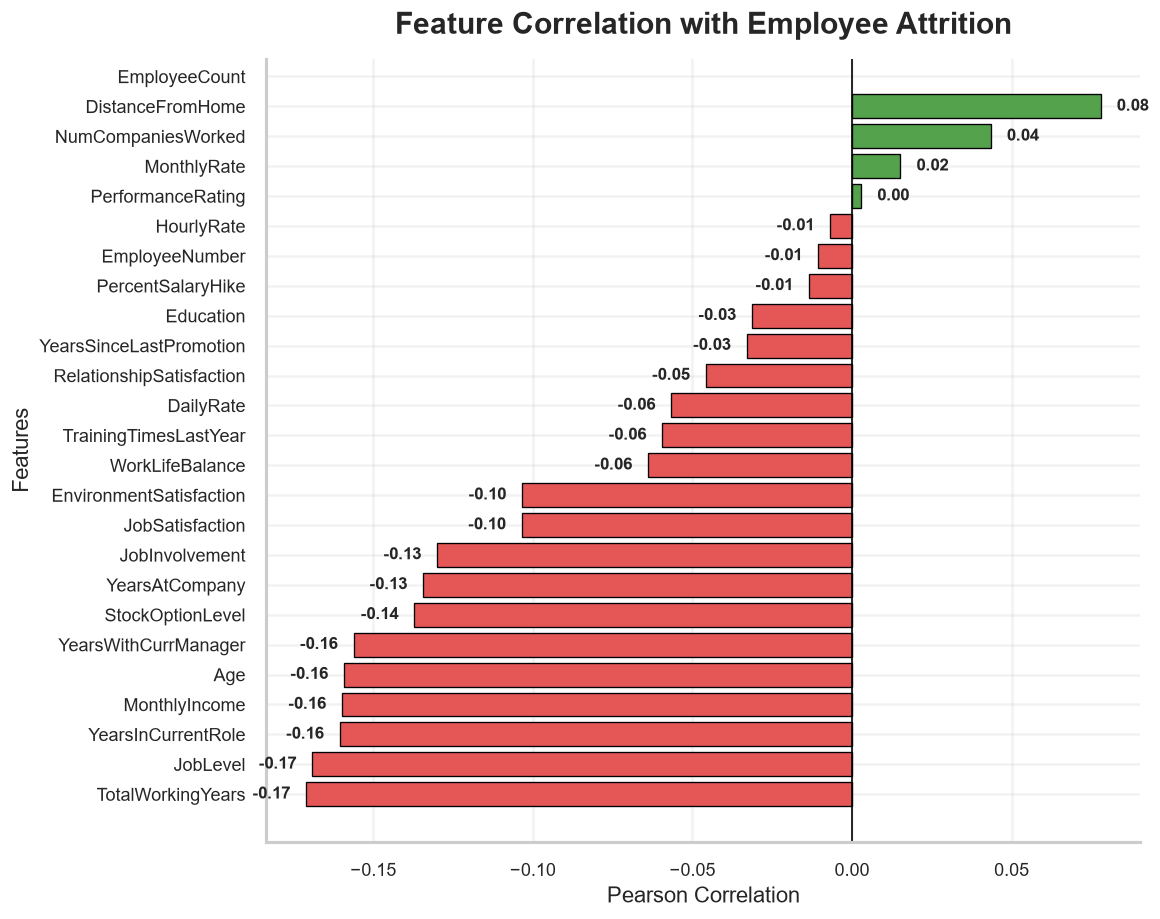

In [ ]:
temp = df.copy()

temp["Attrition"] = temp["Attrition"].map({
    "No": 0,
    "Yes": 1
})

corr = (
    temp.select_dtypes(include=np.number)
        .corr()["Attrition"]
        .drop("Attrition")
        .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))

colors = [
    DANGER if value < 0 else SUCCESS
    for value in corr
]

bars = ax.barh(
    corr.index,
    corr.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

# Add correlation values
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + (0.005 if width >= 0 else -0.005),
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=10,
        fontweight="bold"
    )

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Feature Correlation with Employee Attrition",
    fontsize=18,
    pad=15
)

ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("Features")

sns.despine()

plt.tight_layout()
plt.show()

### Key Findings: Feature Correlation with Attrition

* **Negative Correlation**: `TotalWorkingYears`, `JobLevel`, `MonthlyIncome`, and `Age` are negatively correlated with attrition, meaning older, more experienced, and higher-paid employees are less likely to leave.
* **Positive Correlation**: `DistanceFromHome` and `NumCompaniesWorked` are positively correlated with attrition, suggesting that long commutes and a history of job-hopping increase attrition risk.
* **Weak Linear Influence**: Performance rating, salary hike percentage, and relationship satisfaction show negligible linear correlation with attrition, though non-linear relationships may still be captured by tree-based models.

---

# Key Business Insights

The exploratory analysis reveals several workforce characteristics associated with employee attrition. These findings provide valuable business insights and establish a strong foundation for predictive modeling.

### Workforce Overview

- The organization has an imbalanced attrition distribution, with the majority of employees remaining while a smaller proportion leave.
- Class imbalance should be considered during model training and evaluation.

### Demographic Insights

- Certain age groups appear more susceptible to attrition.
- Marital status may influence employee retention.
- Gender differences, if present, should be interpreted cautiously to avoid unsupported conclusions.

### Job-related Insights

- Employees working overtime generally exhibit higher attrition rates.
- Certain departments and job roles experience greater employee turnover.
- Frequent business travel may contribute to increased attrition.

### Compensation Insights

- Employees with lower monthly income tend to show higher attrition.
- Salary growth and stock options may positively influence retention.

### Experience Insights

- Employees with fewer years at the company or limited professional experience appear more likely to leave.
- Promotion history and manager tenure may influence long-tenured employee retention.

### Employee Satisfaction Insights

- Lower job satisfaction and work-life balance are associated with higher attrition.
- Environment satisfaction and job involvement may also contribute to employee retention.

### Overall Business Conclusion

Employee attrition appears to be influenced by multiple factors rather than a single variable. Compensation, overtime, employee satisfaction, professional experience, and job-related characteristics collectively contribute to turnover risk. These insights will guide feature engineering, preprocessing, and model selection in the subsequent stages of the project.